## Mapping variables, counting NaNs etc.

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

In [3]:
df = pd.read_csv(r"C:\Users\grzeg\Portfolio\Credit-Risk-Prediction\south_german_credit\data\South German Credit.asc", delimiter = " ")

In [4]:
df

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,1,18,4,2,1049,1,2,4,2,1,...,2,21,3,1,1,3,2,1,2,1
1,1,9,4,0,2799,1,3,2,3,1,...,1,36,3,1,2,3,1,1,2,1
2,2,12,2,9,841,2,4,2,2,1,...,1,23,3,1,1,2,2,1,2,1
3,1,12,4,0,2122,1,3,3,3,1,...,1,39,3,1,2,2,1,1,1,1
4,1,12,4,0,2171,1,3,4,3,1,...,2,38,1,2,2,2,2,1,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,24,2,3,1987,1,3,2,3,1,...,1,21,3,1,1,2,1,1,2,0
996,1,24,2,0,2303,1,5,4,3,2,...,1,45,3,2,1,3,2,1,2,0
997,4,21,4,0,12680,5,5,4,3,1,...,4,30,3,3,1,4,2,2,2,0
998,2,12,2,3,6468,5,1,2,3,1,...,4,52,3,2,1,4,2,2,2,0


In [5]:
df['credit_risk'] = df['credit_risk'].map({0:1, 1:0})

In [6]:
mappings = {
    "status": {
        1: "no account",
        2: "<0 DM",
        3: "0 to 200 DM",
        4: ">=200 DM"
    },
    "credit_history": {
        0: "delays",
        1: "critical account",
        2: "no credits",
        3: "all paid_duly",
        4: "paid duly at this bank"
    },
    "purpose": {
        0: "other",
        1: "new car",
        2: "used car",
        3: "furniture",
        4: "radio tv",
        5: "appliances",
        6: "repairs",
        7: "education",
        8: "vacation",
        9: "retraining",
        10: "business"
    },
    "savings": {
        1: "no savings",
        2: "<100 DM",
        3: "100 to 500_DM",
        4: "500 to 1000_DM",
        5: ">=1000 DM"
    },
    "employment_duration": {
        1: "unemployed",
        2: "<1 year",
        3: "1 to 4 years",
        4: "4 to 7 years",
        5: ">=7 years"
    },
    "installment_rate": {
        1: ">=35percent",
        2: "25 to 35 percent",
        3: "20 to 25 percent",
        4: "<20 percent"
    },
    "personal_status": {
        1: "male single",
        2: "female single",
        3: "male married",
        4: "female married"
    },
    "other_debtors": {
        1: "none",
        2: "co applicant",
        3: "guarantor"
    },
    "present_residence": {
        1: "<1 year",
        2: "1 to 4 years",
        3: "4 to 7 years",
        4: ">=7 years"
    },
    "property": {
        1: "none",
        2: "car or other",
        3: "building_savings insurance",
        4: "real estate"
    },
    "other_installment_plans": {
        1: "bank",
        2: "stores",
        3: "none"
    },
    "housing": {
        1: "for free",
        2: "rent",
        3: "own"
    },
    "number_credits": {
        1: "one",
        2: "two to three",
        3: "four to five",
        4: "six or more"
    },
    "job": {
        1: "unemployed unskilled",
        2: "unskilled resident",
        3: "skilled employee official",
        4: "manager self employed"
    },
    "people_liable": {
        1: "3 or more",
        2: "0 to 2"
    },
    "telephone": {
        1: "no",
        2: "yes registered"
    },
    "foreign_worker": {
        1: "yes",
        2: "no"
    },
    "credit_risk": {
        1: "high risk",
        0: "low risk"
    }
}

In [7]:
df_eda = df.copy()

In [8]:
for col, map in mappings.items():
    df_eda[col] = df_eda[col].map(map)

In [9]:
df_eda

,status,duration,credit_history,purpose,amount,savings,employment_duration,installment_rate,personal_status,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,credit_risk
0,no account,18,paid duly at this bank,used car,1049,no savings,<1 year,<20 percent,female single,none,...,car or other,21,none,for free,one,skilled employee official,0 to 2,no,no,low risk
1,no account,9,paid duly at this bank,other,2799,no savings,1 to 4 years,25 to 35 percent,male married,none,...,none,36,none,for free,two to three,skilled employee official,3 or more,no,no,low risk
2,<0 DM,12,no credits,retraining,841,<100 DM,4 to 7 years,25 to 35 percent,female single,none,...,none,23,none,for free,one,unskilled resident,0 to 2,no,no,low risk
3,no account,12,paid duly at this bank,other,2122,no savings,1 to 4 years,20 to 25 percent,male married,none,...,none,39,none,for free,two to three,unskilled resident,3 or more,no,yes,low risk
4,no account,12,paid duly at this bank,other,2171,no savings,1 to 4 years,<20 percent,male married,none,...,car or other,38,bank,rent,two to three,unskilled resident,0 to 2,no,yes,low risk
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,no account,24,no credits,furniture,1987,no savings,1 to 4 years,25 to 35 percent,male married,none,...,none,21,none,for free,one,unskilled resident,3 or more,no,no,high risk
996,no account,24,no credits,other,2303,no savings,>=7 years,<20 percent,male married,co applicant,...,none,45,none,rent,one,skilled employee official,0 to 2,no,no,high risk
997,>=200 DM,21,paid duly at this bank,other,12680,>=1000 DM,>=7 years,<20 percent,male married,none,...,real estate,30,none,own,one,manager self employed,0 to 2,yes registered,no,high risk
998,<0 DM,12,no credits,furniture,6468,>=1000 DM,unemployed,25 to 35 percent,male married,none,...,real estate,52,none,rent,one,manager self employed,0 to 2,yes registered,no,high risk


In [10]:
df_eda.isna().sum()

status                     0
duration                   0
credit_history             0
purpose                    0
amount                     0
savings                    0
employment_duration        0
installment_rate           0
personal_status            0
other_debtors              0
present_residence          0
property                   0
age                        0
other_installment_plans    0
housing                    0
number_credits             0
job                        0
people_liable              0
telephone                  0
foreign_worker             0
credit_risk                0
dtype: int64

In [11]:
colors = sns.color_palette('bright')
sns.set_palette('bright')

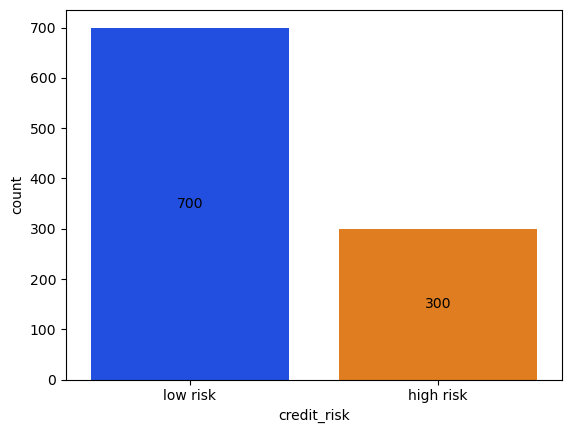

In [12]:
c = sns.countplot(data = df_eda, x = 'credit_risk', hue = 'credit_risk')
for container in c.containers:
    c.bar_label(container, label_type = 'center')

## Numerical variables analysis

In [14]:
numeric = ['age', 'duration', 'amount']

In [15]:
df_eda[numeric].describe()

,age,duration,amount
count,1000.00000,1000.000000,1000.00000
mean,35.54200,20.903000,3271.24800
std,11.35267,12.058814,2822.75176
min,19.00000,4.000000,250.00000
25%,27.00000,12.000000,1365.50000
50%,33.00000,18.000000,2319.50000
75%,42.00000,24.000000,3972.25000
max,75.00000,72.000000,18424.00000


In [16]:
df_eda[numeric]

,age,duration,amount
0,21,18,1049
1,36,9,2799
2,23,12,841
3,39,12,2122
4,38,12,2171
...,...,...,...
995,21,24,1987
996,45,24,2303
997,30,21,12680
998,52,12,6468


In [17]:
titles = [
    'Risk distribution by age',
    'Risk distribution by duration',
    'Risk distribution by amount'
]

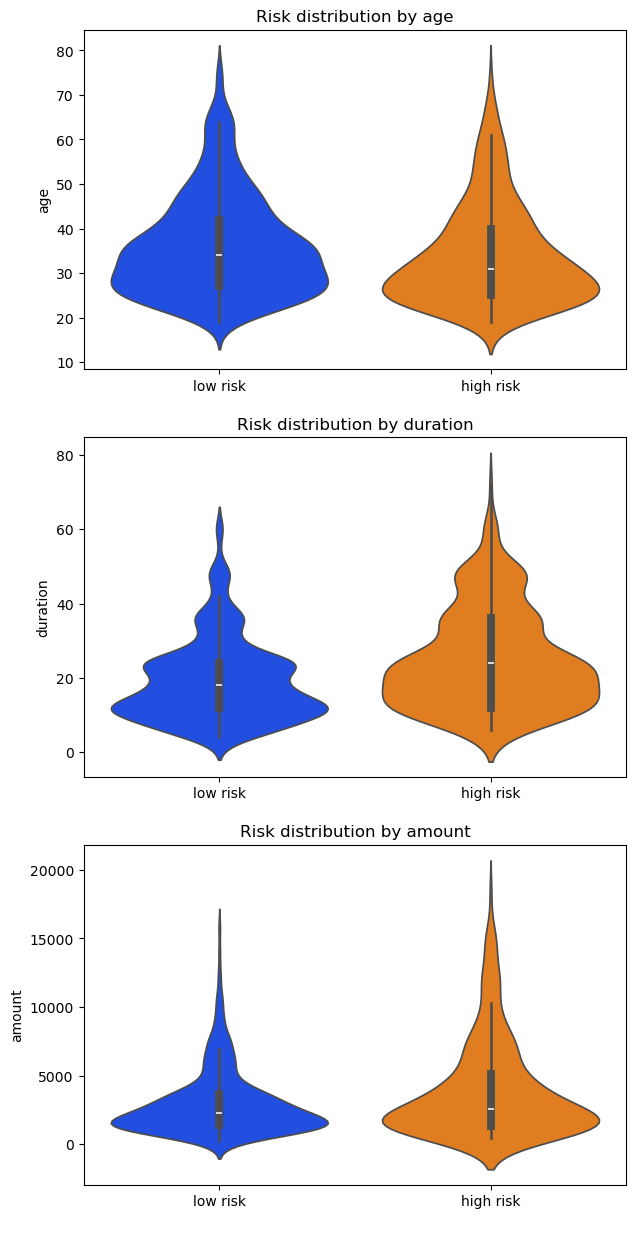

In [18]:
fig, axes = plt.subplots(3,1, figsize = (7,15))
for ax, var, title in zip(axes, numeric, titles):
    sns.violinplot(data = df_eda, x = 'credit_risk', y = var, ax = ax, hue = 'credit_risk')
    ax.set_title(title)
    ax.set_xlabel(" ")

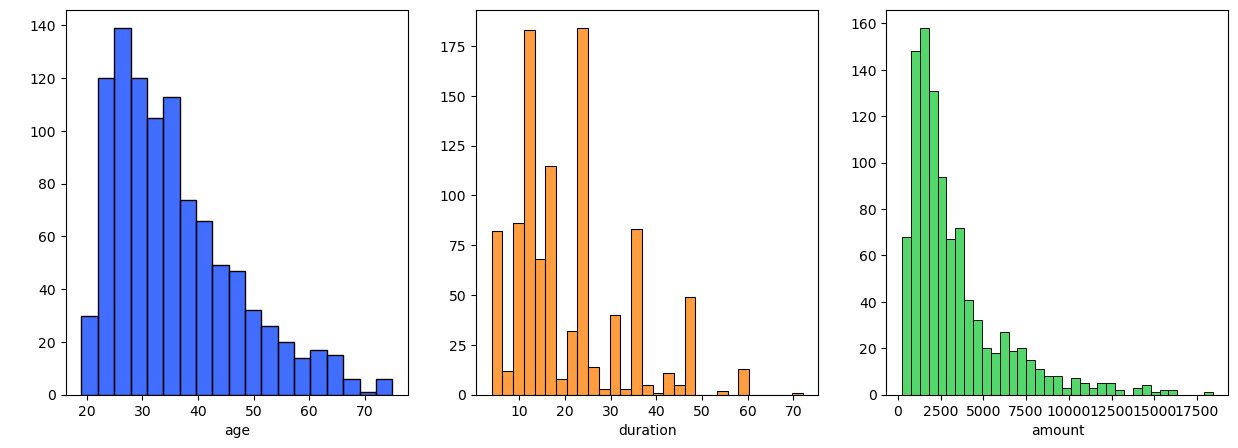

In [19]:
fig, axes = plt.subplots(1,3, figsize = (15,5))
for ax, var, col in zip(axes, numeric, colors):
    sns.histplot(data = df_eda, x = var, ax = ax, color = col)
    ax.set_ylabel(" ")

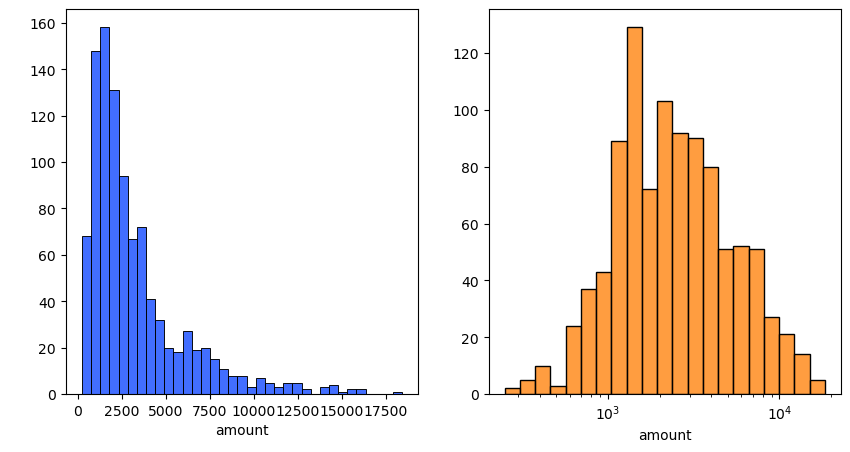

In [20]:
fig, axes = plt.subplots(1,2, figsize = (10, 5))
logs = [False, True]
for ax, col, log in zip(axes, colors, logs):
    sns.histplot(data = df_eda, x = 'amount', ax = ax, color = col, log_scale = log)
    ax.set_ylabel(" ")

In [21]:
pearson = df[numeric+['credit_risk']].corr('pearson')['credit_risk']

In [22]:
pearson = pearson.drop('credit_risk')

In [23]:
pearson.sort_values(ascending = False, inplace = True)

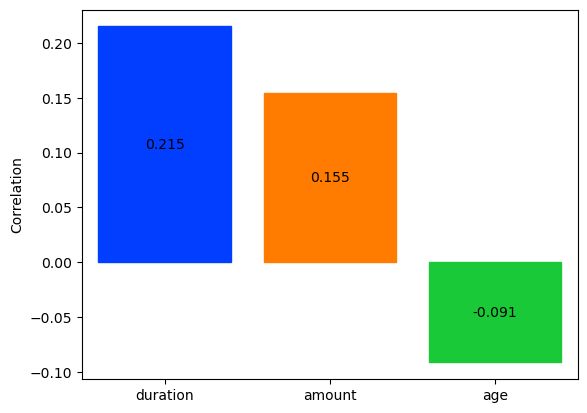

In [121]:
p = sns.barplot(pearson)
for container in p.containers:
    p.bar_label(container, fmt = '%0.3f', label_type = 'center')
for patch, col in zip(p.patches, colors):
    patch.set_color(col)
plt.ylabel('Correlation');

## Ordinal variables analysis

In [81]:
ordinal = [
    "status",
    "savings",
    "employment_duration",
    "installment_rate",
    "present_residence",
    "number_credits"
]

In [89]:
spearman = df[ordinal + ['credit_risk']].corr('spearman')['credit_risk']

In [91]:
spearman.drop('credit_risk', inplace = True)

In [97]:
spearman.sort_values(inplace = True)

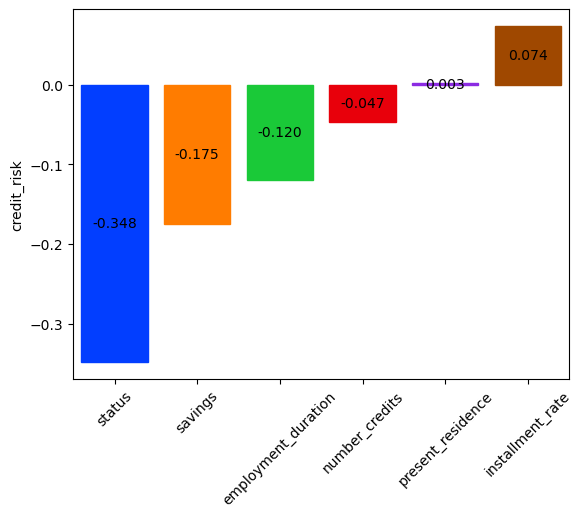

In [119]:
s = sns.barplot(spearman)
plt.xticks(rotation = 45)
for patch, col in zip(s.patches, colors):
    patch.set_color(col)
for container in s.containers:
    s.bar_label(container, fmt = '%0.3f', label_type = 'center');

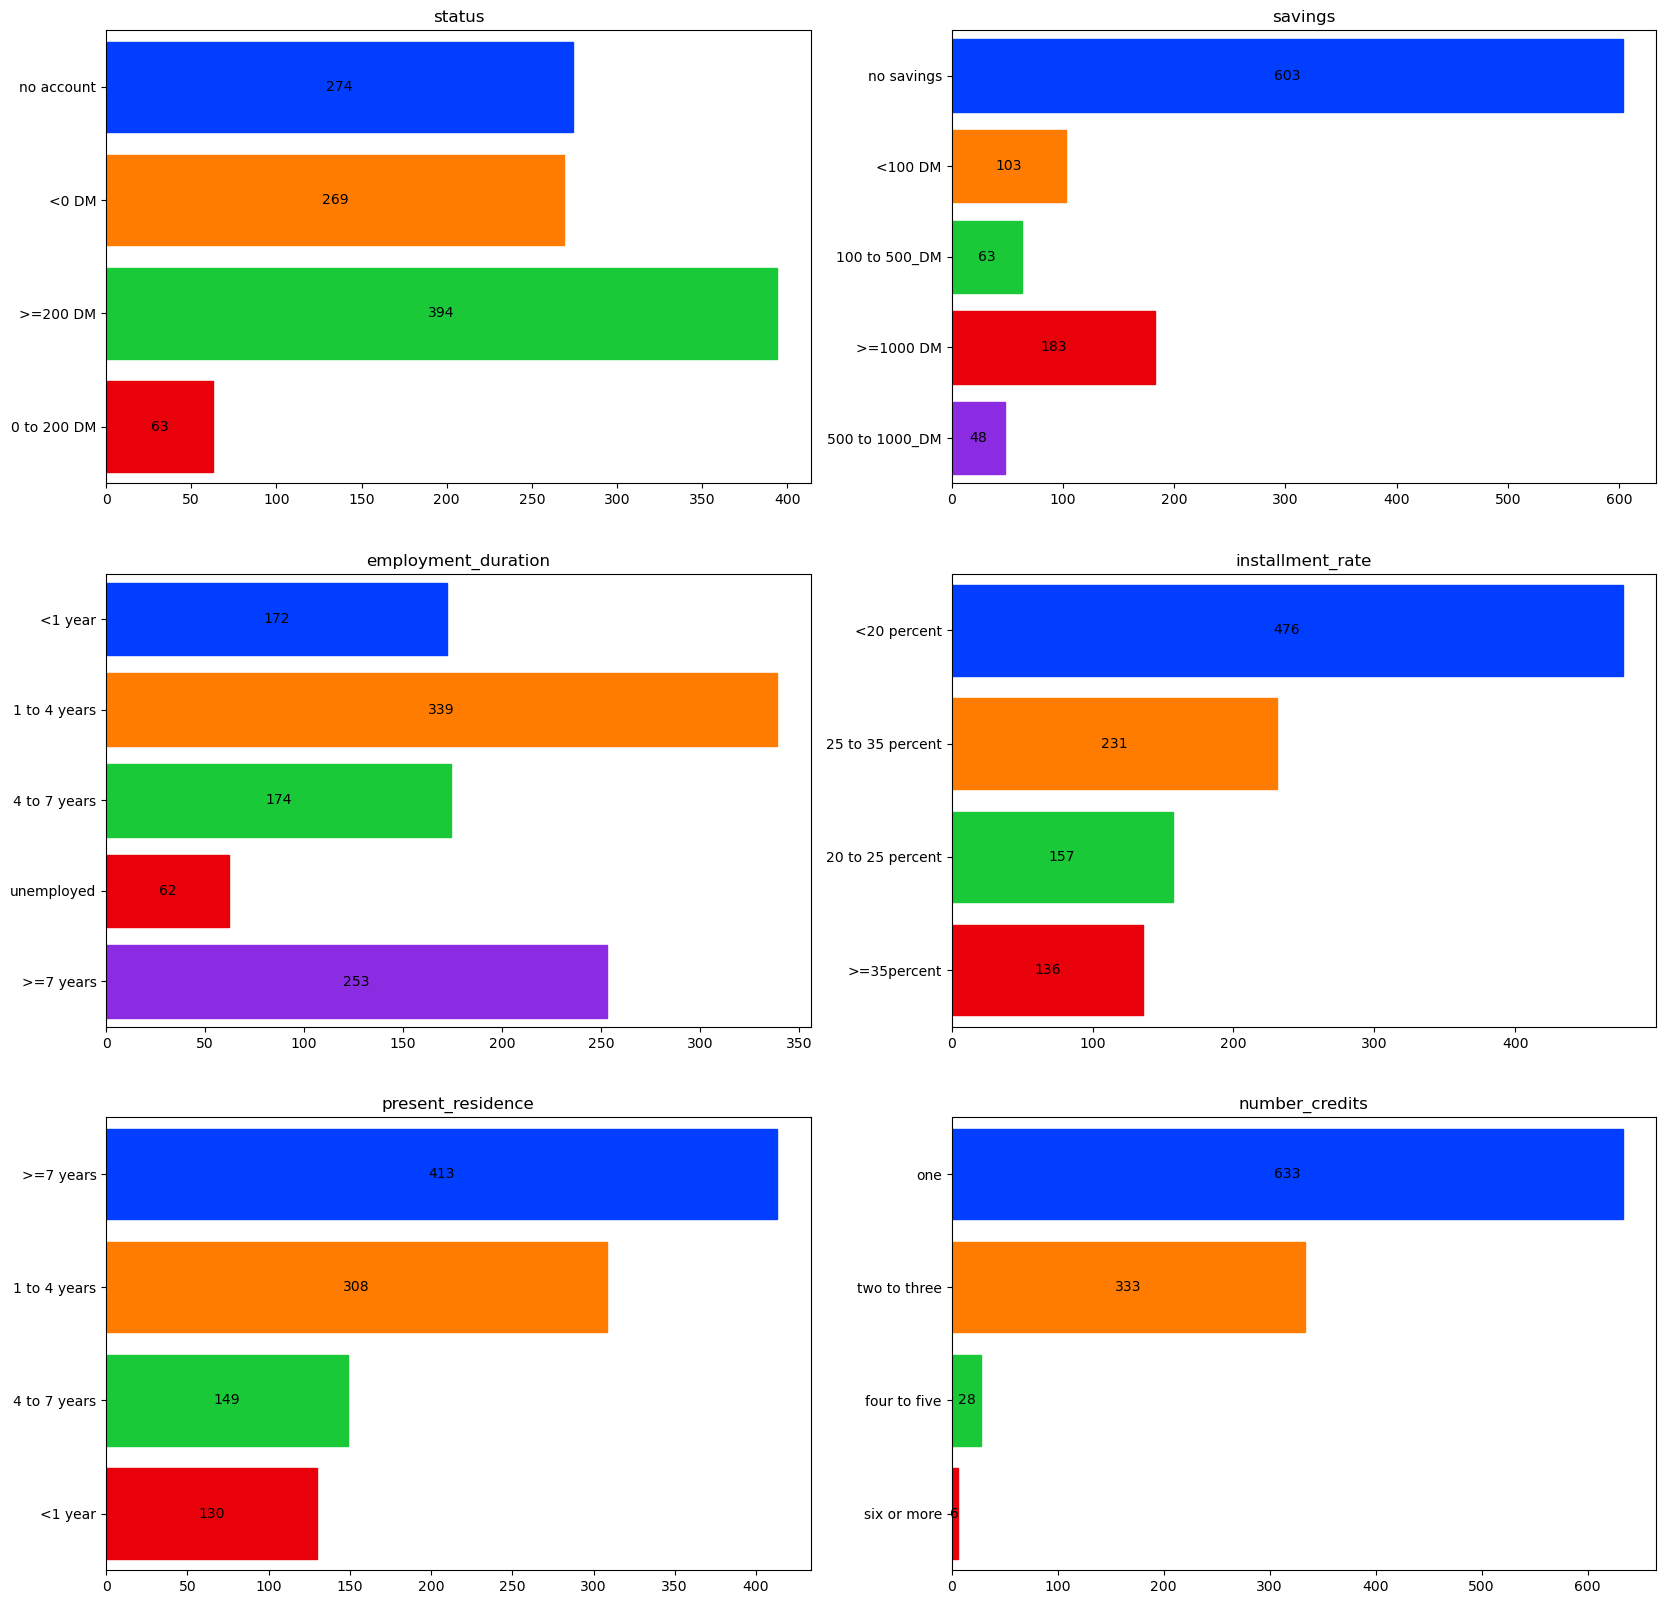

In [167]:
fig, axes = plt.subplots(3,2, figsize = (20,20))
for ax, var in zip(axes.flat, ordinal):
    c = sns.countplot(data = df_eda, y = var, ax = ax)
    for patch, col in zip(c.patches, colors):
        patch.set_color(col)
    for container in c.containers:
        c.bar_label(container, label_type = 'center')
    ax.set_ylabel("")
    ax.set_xlabel("")
    ax.set_title(var)

In [191]:
pd.crosstab(df_eda['status'], df_eda['credit_risk'], normalize = 'index')

credit_risk,high risk,low risk
status,,
0 to 200 DM,0.222222,0.777778
<0 DM,0.390335,0.609665
>=200 DM,0.116751,0.883249
no account,0.492701,0.507299


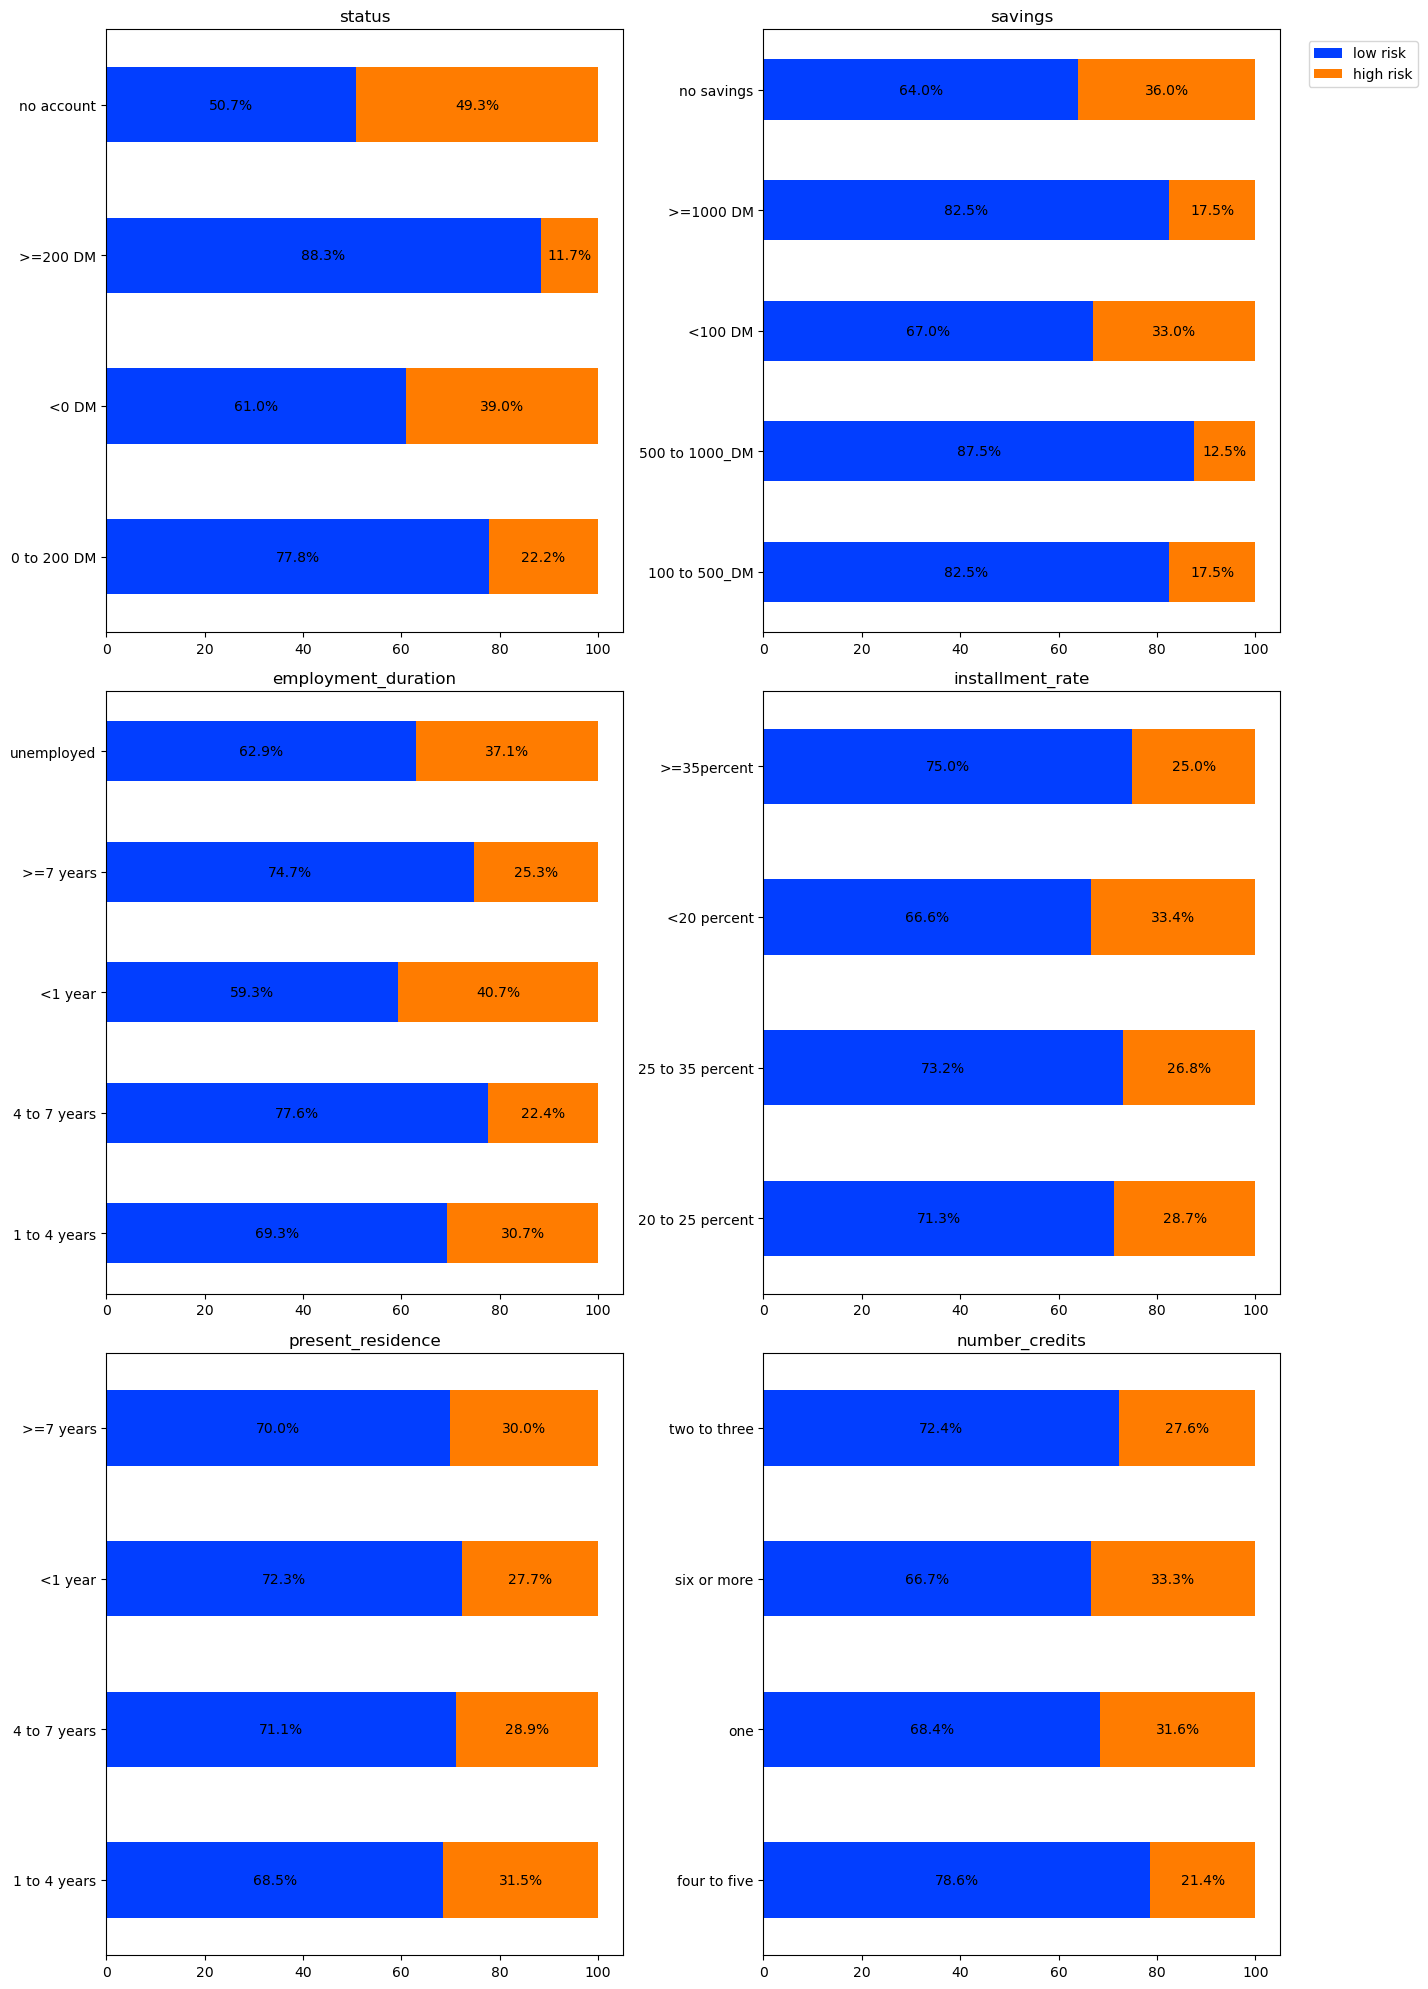

In [251]:
risk_order = ["low risk", "high risk"]
fig, axes = plt.subplots(3,2, figsize = (13,20))
for ax, var in zip(axes.flat, ordinal):
    cross = pd.crosstab(df_eda[var], df_eda['credit_risk'], normalize = 'index')*100
    cross = cross[risk_order]
    c_plot = cross.plot(kind = 'barh', stacked = True, ax = ax, legend = False)
    ax.set_ylabel("")
    ax.set_title(var)
    for container in ax.containers:
        c_plot.bar_label(container, fmt = '%.1f%%', label_type = 'center')
fig.legend(["low risk", "high risk"], loc="upper right", bbox_to_anchor=(1.1, 0.98))
plt.tight_layout()